#1. Імпорт всіх необхідних бібліотек

In [ ]:
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import warnings
import time
from pathlib import Path
import importlib
import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import evaluate_model, plot_cm


In [ ]:
!pip install -q sentence-transformers

In [ ]:
pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)
pd.set_option("display.max_colwidth",None)

warnings.filterwarnings('ignore')

#2. Оцінювання фінальної моделі на тестовому наборі даних

##2.1 Завантаження та обробка тестових даних

За результатами порівняння моделей як фінальну було обрано модель SentenceTransformer + Logistic Regression. На даному етапі виконаємо її оцінювання на незалежному тестовому наборі даних.


In [ ]:
test_df = pd.read_csv("data/test.csv.zip")
X_test = test_df["text"]
y_test = test_df["category"]

In [ ]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
st_model = joblib.load("models/sentence_transformer_logreg.joblib")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
X_test_emb = embedder.encode(
    X_test.tolist(),
    batch_size=64,
    convert_to_numpy=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/490 [00:00<?, ?it/s]

##2.2 Формування передбачень та порівняння метрик

In [ ]:
test_accuracy, test_macro_f1, test_weighted_f1, y_test_pred = evaluate_model(
    st_model,
    X_test_emb,
    y_test
)

In [ ]:
results = pd.DataFrame({
    "Dataset": ["Test"],
    "Accuracy": [test_accuracy],
    "Macro F1": [test_macro_f1],
    "Weighted F1": [test_weighted_f1]
})
results

,Dataset,Accuracy,Macro F1,Weighted F1
0,Test,0.6094,0.4782,0.5902


##2.3 Детальний classification report

In [ ]:
print(classification_report(y_test, y_test_pred))

                precision    recall  f1-score   support

          ARTS       0.40      0.29      0.34       226
ARTS & CULTURE       0.33      0.20      0.25       200
  BLACK VOICES       0.49      0.36      0.41       687
      BUSINESS       0.51      0.50      0.50       898
       COLLEGE       0.48      0.42      0.45       172
        COMEDY       0.46      0.36      0.41       808
         CRIME       0.52      0.53      0.52       534
CULTURE & ARTS       0.52      0.24      0.33       161
       DIVORCE       0.76      0.70      0.73       513
     EDUCATION       0.52      0.41      0.46       152
 ENTERTAINMENT       0.60      0.75      0.67      2604
   ENVIRONMENT       0.49      0.25      0.33       217
         FIFTY       0.52      0.24      0.33       210
  FOOD & DRINK       0.63      0.78      0.70       951
     GOOD NEWS       0.35      0.23      0.28       210
         GREEN       0.40      0.42      0.41       392
HEALTHY LIVING       0.43      0.20      0.27  

##2.4 Матриця помилок

Побудуємо нормалізовану матрицю помилок тестового набору даних:

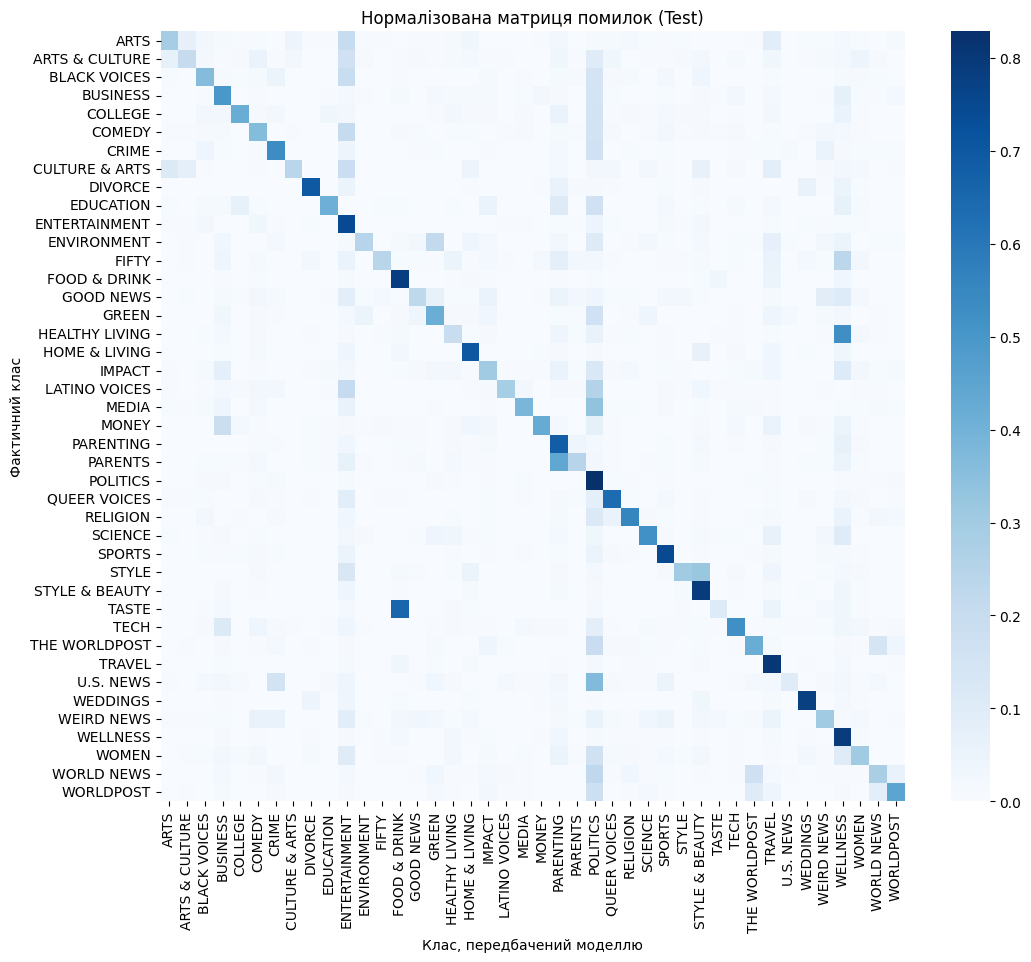

In [ ]:
plot_cm(y_test, y_test_pred, "Test")

##2.5 Аналіз помилок моделі

In [ ]:
errors = pd.DataFrame({
    "text": X_test,
    "true_category": y_test,
    "predicted_category": y_test_pred
})

errors = errors[
    errors["true_category"] != errors["predicted_category"]
]

errors.head(20)

,text,true_category,predicted_category
1,It's About Time: When Is as Important as What in Eating,HEALTHY LIVING,WELLNESS
2,"Shailene Woodley Recalls Violent Thanksgiving History In New Standing Rock Video “Thanksgiving was founded on a massacre and yet we’re here with cops and snipers.""",ENTERTAINMENT,BLACK VOICES
3,Bacardi: A Rum Story,TASTE,FOOD & DRINK
5,The Constant Dread of Defense For years I avoided engaging in discussions about the Israel/Arab situation -- I just didn't want to deal with it. That all changed about three-and-a-half years ago when my parents moved to Jerusalem. Now my immediate family is there and my comfort in the ability to duck the debate vanished.,POLITICS,WORLDPOST
8,"Why My Children Will Not Play Cops And Robbers Until the image and aims of law enforcement change, I am not comfortable with my children aspiring to join their ranks",BLACK VOICES,PARENTING
9,Proof That One Man's Creepy Face Changes A Book's Entire Meaning Creep Lit 101.,COMEDY,ARTS & CULTURE
12,"The Problem With Friday Night Tykes The new show, Esquire's Friday Night Tykes, is getting quite a bit of attention. I suppose this was exactly the network's intent but there are very few cells in my body that can stay quiet about this. Reality TV has submerged to profound depths.",PARENTING,ENTERTAINMENT
13,"Mobile Food Pantries Bring Fresh Produce to Neglected Communities By taking clients at their word and allowing them to choose from an array of truly healthy foods, Arnold ushered in a new era of food banking, one that is more efficient, more nourishing, and more responsive to those it serves.",IMPACT,FOOD & DRINK
17,"Earth Day, Conspiracy and World Government The behaviors we need to protect the environment are not particularly oppressive. Indeed, many are things we'd want to do anyways. But they're often a big change from what we're currently doing.",ENVIRONMENT,GREEN
20,Kerry Washington Gets Pretty In Polka Dots & More Of The Week's Best Style Moments (PHOTOS) Ciara rounds up our top looks of the week with the sexy getup she wore to the Givenchy show during Paris Fashion Week. The,BLACK VOICES,STYLE & BEAUTY


In [ ]:
print(f"Кількість помилок: {len(errors)}")
print(f"Частка помилок: {len(errors) / len(y_test):.2%}")

Кількість помилок: 12247
Частка помилок: 39.06%


In [ ]:
errors_pairs = (
    errors
    .groupby(["true_category", "predicted_category"])
    .size()
    .sort_values(ascending=False)
)

errors_pairs.head(15)

,,0
true_category,predicted_category,
HEALTHY LIVING,WELLNESS,526
PARENTS,PARENTING,258
TASTE,FOOD & DRINK,206
COMEDY,ENTERTAINMENT,167
MEDIA,POLITICS,149
BLACK VOICES,ENTERTAINMENT,134
BUSINESS,POLITICS,132
COMEDY,POLITICS,127
WORLD NEWS,POLITICS,112


#3. Висновки

Фінальна модель SentenceTransformer + Logistic Regression продемонструвала найкращі результати серед усіх протестованих моделей та була оцінена на незалежному тестовому наборі даних.

Отримані результати підтвердили її здатність ефективно класифікувати нові текстові дані та узагальнювати інформацію, що не використовувалася під час навчання.
